In [1]:
import pandas as pd
import numpy as np
from tensorflow import keras

from sklearn import datasets, linear_model
from sklearn.linear_model import LinearRegression

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Make numpy values easier to read.
np.set_printoptions(precision=3, suppress=True)

import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras import preprocessing

In [2]:
dataset = pd.read_csv(
    "G:/giscourse/project/datatoMakemodel/dataset_toMakemodel.csv", header=0)

In [3]:
# dataset['Area_planted_Acr_f'] = dataset['Area_planted_Acr_f'] * 0.404686

In [4]:
dataset

,Unnamed: 0,latitude,longitude,ndvi,gndvi,savi,evi,County,Year,Area_planted_Acr_f,yield_Bu_Acr_f,yield_total_Bu
0,0,40.745740,-84.936135,0.864546,8.262665,1.296773,18.822446,ADAMS,2014,64000.0,183.3,11731200.0
1,1,41.091863,-85.072235,0.849503,8.167988,1.274335,22.839722,ALLEN,2014,82000.0,185.8,15235600.0
2,2,39.206483,-85.893663,0.608369,3.347106,0.912521,12.452923,BARTHOLOMEW,2014,60000.0,200.3,12018000.0
3,3,40.608260,-87.315485,0.898764,9.688027,1.348978,6.348873,BENTON,2014,130000.0,202.4,26312000.0
4,4,40.474668,-85.326241,0.677666,4.744491,1.016690,14.957222,BLACKFORD,2014,32500.0,157.1,5105750.0
...,...,...,...,...,...,...,...,...,...,...,...,...
476,476,38.089770,-87.298307,0.849386,7.886705,1.281135,29.812472,WARRICK,2019,36000.0,156.5,5634000.0
477,477,38.600620,-86.104756,0.746633,5.453854,1.120373,15.149207,WASHINGTON,2019,45000.0,134.3,6043500.0
478,478,39.863098,-85.006740,0.891594,8.966701,1.347580,17.620357,WAYNE,2019,61000.0,167.5,10217500.0
479,479,40.748952,-86.888849,0.876617,9.316898,1.314930,7.654961,WHITE,2019,135000.0,177.6,23976000.0


In [5]:
train_all = dataset[dataset['Year']!= 2019]
train_all

,Unnamed: 0,latitude,longitude,ndvi,gndvi,savi,evi,County,Year,Area_planted_Acr_f,yield_Bu_Acr_f,yield_total_Bu
0,0,40.745740,-84.936135,0.864546,8.262665,1.296773,18.822446,ADAMS,2014,64000.0,183.3,11731200.0
1,1,41.091863,-85.072235,0.849503,8.167988,1.274335,22.839722,ALLEN,2014,82000.0,185.8,15235600.0
2,2,39.206483,-85.893663,0.608369,3.347106,0.912521,12.452923,BARTHOLOMEW,2014,60000.0,200.3,12018000.0
3,3,40.608260,-87.315485,0.898764,9.688027,1.348978,6.348873,BENTON,2014,130000.0,202.4,26312000.0
4,4,40.474668,-85.326241,0.677666,4.744491,1.016690,14.957222,BLACKFORD,2014,32500.0,157.1,5105750.0
...,...,...,...,...,...,...,...,...,...,...,...,...
408,408,38.600620,-86.104756,0.896007,11.011435,1.343924,9.617093,WASHINGTON,2018,37200.0,184.1,6848520.0
409,409,39.863098,-85.006740,0.886975,9.389760,1.330730,41.895976,WAYNE,2018,62000.0,191.7,11885400.0
410,410,40.749954,-85.212428,0.894653,10.129063,1.342205,7.160000,WELLS,2018,75000.0,204.1,15307500.0
411,411,40.748952,-86.888849,0.892409,10.241195,1.338905,9.045582,WHITE,2018,135000.0,196.9,26581500.0


In [6]:
test_all = dataset[dataset['Year']==2019].reset_index(drop = True)
test_all

,Unnamed: 0,latitude,longitude,ndvi,gndvi,savi,evi,County,Year,Area_planted_Acr_f,yield_Bu_Acr_f,yield_total_Bu
0,413,40.745740,-84.936135,0.848317,7.503676,1.274267,24.595310,ADAMS,2019,40000.0,170.1,6804000.0
1,414,41.091863,-85.072235,0.733248,5.745552,1.101435,30.529547,ALLEN,2019,53000.0,181.4,9614200.0
2,415,40.608260,-87.315485,0.880978,9.454374,1.321387,2.677317,BENTON,2019,123000.0,186.0,22878000.0
3,416,40.050899,-86.469019,0.813557,7.233196,1.220665,7.096993,BOONE,2019,72000.0,177.4,12772800.0
4,417,40.584988,-86.565147,0.884565,9.792332,1.327004,13.060968,CARROLL,2019,93000.0,194.6,18097800.0
...,...,...,...,...,...,...,...,...,...,...,...,...
63,476,38.089770,-87.298307,0.849386,7.886705,1.281135,29.812472,WARRICK,2019,36000.0,156.5,5634000.0
64,477,38.600620,-86.104756,0.746633,5.453854,1.120373,15.149207,WASHINGTON,2019,45000.0,134.3,6043500.0
65,478,39.863098,-85.006740,0.891594,8.966701,1.347580,17.620357,WAYNE,2019,61000.0,167.5,10217500.0
66,479,40.748952,-86.888849,0.876617,9.316898,1.314930,7.654961,WHITE,2019,135000.0,177.6,23976000.0


In [7]:
train = train_all[['ndvi','gndvi','evi','Area_planted_Acr_f','yield_total_Bu']]
test = test_all[['ndvi','gndvi','evi','Area_planted_Acr_f','yield_total_Bu']]
predictor_train = train[['ndvi','gndvi','evi','Area_planted_Acr_f']]
corn_train =train['yield_total_Bu']
test_x = test[['ndvi','gndvi','evi','Area_planted_Acr_f']]
test_y = test['yield_total_Bu']

In [8]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()


In [9]:
predictor_array = np.array(predictor_train)
corn_train_array = np.array(corn_train)
testX_array = np.array(test_x)
testy_array = np.array(test_y)

In [10]:
# predictor_array = sc_X.fit_transform(predictor_array)
# corn_train_array = corn_train_array.reshape(-1,1)
# corn_train_array = sc_y.fit_transform(corn_train_array)
              

In [11]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('loss')<9.9 and logs.get('val_loss')<8 ):
      print("\nReached max accuracy so cancelling training!")
      self.model.stop_training = True

In [12]:
callbacks = myCallback()

In [13]:
from tensorflow.keras import backend as K
def r2_keras(transtrain_labels_true, transtrain_labels_pred):
    SS_res =  K.sum(K.square(transtrain_labels_true - transtrain_labels_pred)) 
    SS_tot = K.sum(K.square(transtrain_labels_true - K.mean(transtrain_labels_true))) 
    return ( 1 - SS_res/(SS_tot + K.epsilon()))

In [14]:
model = tf.keras.Sequential([
   
    layers.Dense(180),
#     layers.Dense(180),
       
    layers.Dense(128),
#     layers.Dense(128),
    
    layers.Dense(64),
    layers.Dense(64),
    layers.Dense(32),
#     layers.Dense(32),
    
    layers.Dense(1)
])

model.compile(loss = tf.losses.MeanAbsolutePercentageError(),
                      optimizer = tf.optimizers.Adam(), metrics=['MeanAbsolutePercentageError','mse', 'mae', r2_keras])

In [15]:
history= model.fit(predictor_array,corn_train_array, epochs=4000, callbacks= [callbacks], validation_split= .1)

Epoch 1/4000
12/12 [==============================] - 0s 29ms/step - loss: 97.4040 - mean_absolute_percentage_error: 97.4040 - mse: 154808002543616.0000 - mae: 10820139.0000 - r2_keras: -3.0783 - val_loss: 91.9903 - val_mean_absolute_percentage_error: 91.9903 - val_mse: 134712236441600.0000 - val_mae: 10075170.0000 - val_r2_keras: -2.9392
Epoch 2/4000
12/12 [==============================] - 0s 4ms/step - loss: 75.0198 - mean_absolute_percentage_error: 75.0198 - mse: 97210360397824.0000 - mae: 8388952.0000 - r2_keras: -1.5754 - val_loss: 42.8273 - val_mean_absolute_percentage_error: 42.8273 - val_mse: 31479348330496.0000 - val_mae: 4787668.5000 - val_r2_keras: 0.0512
Epoch 3/4000
12/12 [==============================] - 0s 3ms/step - loss: 19.9711 - mean_absolute_percentage_error: 19.9711 - mse: 9163272880128.0000 - mae: 2111124.0000 - r2_keras: 0.7506 - val_loss: 13.8639 - val_mean_absolute_percentage_error: 13.8639 - val_mse: 4366041874432.0000 - val_mae: 1630519.2500 - val_r2_keras:

Epoch 26/4000
12/12 [==============================] - 0s 3ms/step - loss: 10.4397 - mean_absolute_percentage_error: 10.4397 - mse: 2945738342400.0000 - mae: 1153163.3750 - r2_keras: 0.9137 - val_loss: 13.8691 - val_mean_absolute_percentage_error: 13.8691 - val_mse: 4334615789568.0000 - val_mae: 1625647.3750 - val_r2_keras: 0.8613
Epoch 27/4000
12/12 [==============================] - 0s 4ms/step - loss: 10.8338 - mean_absolute_percentage_error: 10.8338 - mse: 3205517279232.0000 - mae: 1220740.1250 - r2_keras: 0.8930 - val_loss: 13.2800 - val_mean_absolute_percentage_error: 13.2800 - val_mse: 4000683393024.0000 - val_mae: 1558328.5000 - val_r2_keras: 0.8718
Epoch 28/4000
12/12 [==============================] - 0s 4ms/step - loss: 10.4098 - mean_absolute_percentage_error: 10.4098 - mse: 3091260768256.0000 - mae: 1164158.2500 - r2_keras: 0.9152 - val_loss: 10.3415 - val_mean_absolute_percentage_error: 10.3415 - val_mse: 2590363877376.0000 - val_mae: 1223663.0000 - val_r2_keras: 0.9170
E

12/12 [==============================] - 0s 3ms/step - loss: 10.2202 - mean_absolute_percentage_error: 10.2202 - mse: 3038030594048.0000 - mae: 1154718.2500 - r2_keras: 0.9135 - val_loss: 10.2663 - val_mean_absolute_percentage_error: 10.2663 - val_mse: 2533168775168.0000 - val_mae: 1210233.5000 - val_r2_keras: 0.9189
Epoch 51/4000
12/12 [==============================] - 0s 3ms/step - loss: 10.2034 - mean_absolute_percentage_error: 10.2034 - mse: 3125956837376.0000 - mae: 1168926.0000 - r2_keras: 0.9120 - val_loss: 8.2175 - val_mean_absolute_percentage_error: 8.2175 - val_mse: 1722953367552.0000 - val_mae: 978810.6875 - val_r2_keras: 0.9463
Epoch 52/4000
12/12 [==============================] - 0s 4ms/step - loss: 10.2626 - mean_absolute_percentage_error: 10.2626 - mse: 3031827742720.0000 - mae: 1150070.0000 - r2_keras: 0.9122 - val_loss: 11.0408 - val_mean_absolute_percentage_error: 11.0408 - val_mse: 2863852683264.0000 - val_mae: 1296513.8750 - val_r2_keras: 0.9081
Epoch 53/4000
12/1

Epoch 75/4000
12/12 [==============================] - 0s 4ms/step - loss: 10.3527 - mean_absolute_percentage_error: 10.3527 - mse: 2994464358400.0000 - mae: 1136869.3750 - r2_keras: 0.9180 - val_loss: 12.1308 - val_mean_absolute_percentage_error: 12.1308 - val_mse: 3339253710848.0000 - val_mae: 1415592.0000 - val_r2_keras: 0.8929
Epoch 76/4000
12/12 [==============================] - 0s 3ms/step - loss: 10.7879 - mean_absolute_percentage_error: 10.7879 - mse: 3312610443264.0000 - mae: 1212564.8750 - r2_keras: 0.9136 - val_loss: 10.5323 - val_mean_absolute_percentage_error: 10.5323 - val_mse: 2617570492416.0000 - val_mae: 1233567.7500 - val_r2_keras: 0.9162
Epoch 77/4000
12/12 [==============================] - 0s 3ms/step - loss: 10.2722 - mean_absolute_percentage_error: 10.2722 - mse: 3023224176640.0000 - mae: 1155781.1250 - r2_keras: 0.9179 - val_loss: 9.9481 - val_mean_absolute_percentage_error: 9.9481 - val_mse: 2367599411200.0000 - val_mae: 1168823.7500 - val_r2_keras: 0.9244
Epo

Epoch 100/4000
12/12 [==============================] - 0s 3ms/step - loss: 10.1364 - mean_absolute_percentage_error: 10.1364 - mse: 3085741064192.0000 - mae: 1142841.1250 - r2_keras: 0.9169 - val_loss: 11.4180 - val_mean_absolute_percentage_error: 11.4180 - val_mse: 2977157349376.0000 - val_mae: 1328411.0000 - val_r2_keras: 0.9045
Epoch 101/4000
12/12 [==============================] - 0s 3ms/step - loss: 10.4562 - mean_absolute_percentage_error: 10.4562 - mse: 2975226658816.0000 - mae: 1151180.0000 - r2_keras: 0.9220 - val_loss: 12.7850 - val_mean_absolute_percentage_error: 12.7850 - val_mse: 3636684390400.0000 - val_mae: 1484531.2500 - val_r2_keras: 0.8834
Epoch 102/4000
12/12 [==============================] - 0s 3ms/step - loss: 10.3400 - mean_absolute_percentage_error: 10.3400 - mse: 3093990735872.0000 - mae: 1185974.2500 - r2_keras: 0.9195 - val_loss: 10.3385 - val_mean_absolute_percentage_error: 10.3385 - val_mse: 2506824876032.0000 - val_mae: 1206441.3750 - val_r2_keras: 0.919

...

12/12 [==============================] - 0s 4ms/step - loss: 10.6212 - mean_absolute_percentage_error: 10.6212 - mse: 3126868574208.0000 - mae: 1171551.2500 - r2_keras: 0.9173 - val_loss: 12.0605 - val_mean_absolute_percentage_error: 12.0605 - val_mse: 3155880574976.0000 - val_mae: 1378581.7500 - val_r2_keras: 0.8989
Epoch 1813/4000
12/12 [==============================] - 0s 4ms/step - loss: 10.2768 - mean_absolute_percentage_error: 10.2768 - mse: 3057175232512.0000 - mae: 1140919.5000 - r2_keras: 0.9198 - val_loss: 10.7420 - val_mean_absolute_percentage_error: 10.7420 - val_mse: 2561257242624.0000 - val_mae: 1227263.2500 - val_r2_keras: 0.9182
Epoch 1814/4000
12/12 [==============================] - 0s 5ms/step - loss: 10.0372 - mean_absolute_percentage_error: 10.0372 - mse: 2987207426048.0000 - mae: 1135244.6250 - r2_keras: 0.9172 - val_loss: 9.3110 - val_mean_absolute_percentage_error: 9.3110 - val_mse: 1976434294784.0000 - val_mae: 1067890.3750 - val_r2_keras: 0.9378
Epoch 1815/40

Epoch 1837/4000
12/12 [==============================] - 0s 3ms/step - loss: 10.1702 - mean_absolute_percentage_error: 10.1702 - mse: 3051552243712.0000 - mae: 1161461.2500 - r2_keras: 0.9206 - val_loss: 8.5818 - val_mean_absolute_percentage_error: 8.5818 - val_mse: 1725220257792.0000 - val_mae: 987688.6875 - val_r2_keras: 0.9464
Epoch 1838/4000
12/12 [==============================] - 0s 4ms/step - loss: 10.1118 - mean_absolute_percentage_error: 10.1118 - mse: 2895667265536.0000 - mae: 1132554.6250 - r2_keras: 0.9243 - val_loss: 8.9502 - val_mean_absolute_percentage_error: 8.9502 - val_mse: 1849342951424.0000 - val_mae: 1027684.0000 - val_r2_keras: 0.9421
Epoch 1839/4000
12/12 [==============================] - 0s 2ms/step - loss: 10.2595 - mean_absolute_percentage_error: 10.2595 - mse: 3117609123840.0000 - mae: 1155375.7500 - r2_keras: 0.9110 - val_loss: 11.3048 - val_mean_absolute_percentage_error: 11.3048 - val_mse: 2809837649920.0000 - val_mae: 1290686.6250 - val_r2_keras: 0.9101


Epoch 1862/4000
12/12 [==============================] - 0s 3ms/step - loss: 10.0256 - mean_absolute_percentage_error: 10.0256 - mse: 2956074156032.0000 - mae: 1138864.8750 - r2_keras: 0.9232 - val_loss: 8.4628 - val_mean_absolute_percentage_error: 8.4628 - val_mse: 1688120721408.0000 - val_mae: 975574.5625 - val_r2_keras: 0.9477
Epoch 1863/4000
12/12 [==============================] - 0s 3ms/step - loss: 9.9955 - mean_absolute_percentage_error: 9.9955 - mse: 2938503168000.0000 - mae: 1106997.6250 - r2_keras: 0.9190 - val_loss: 10.6585 - val_mean_absolute_percentage_error: 10.6585 - val_mse: 2526162976768.0000 - val_mae: 1218128.2500 - val_r2_keras: 0.9194
Epoch 1864/4000
12/12 [==============================] - 0s 3ms/step - loss: 10.1027 - mean_absolute_percentage_error: 10.1027 - mse: 2977170718720.0000 - mae: 1135383.5000 - r2_keras: 0.9068 - val_loss: 9.7700 - val_mean_absolute_percentage_error: 9.7700 - val_mse: 2152341831680.0000 - val_mae: 1119309.1250 - val_r2_keras: 0.9318
Ep

Epoch 1887/4000
12/12 [==============================] - 0s 3ms/step - loss: 9.9725 - mean_absolute_percentage_error: 9.9725 - mse: 2890446929920.0000 - mae: 1112055.8750 - r2_keras: 0.9270 - val_loss: 10.6766 - val_mean_absolute_percentage_error: 10.6766 - val_mse: 2529447641088.0000 - val_mae: 1219229.7500 - val_r2_keras: 0.9193
Epoch 1888/4000
12/12 [==============================] - 0s 3ms/step - loss: 10.1040 - mean_absolute_percentage_error: 10.1040 - mse: 2910017814528.0000 - mae: 1125849.5000 - r2_keras: 0.9188 - val_loss: 10.5467 - val_mean_absolute_percentage_error: 10.5467 - val_mse: 2478084194304.0000 - val_mae: 1205524.0000 - val_r2_keras: 0.9210
Epoch 1889/4000
12/12 [==============================] - 0s 3ms/step - loss: 10.2714 - mean_absolute_percentage_error: 10.2714 - mse: 3130694303744.0000 - mae: 1182572.7500 - r2_keras: 0.9130 - val_loss: 7.4810 - val_mean_absolute_percentage_error: 7.4810 - val_mse: 1363398623232.0000 - val_mae: 862390.6875 - val_r2_keras: 0.9595


Epoch 1912/4000
12/12 [==============================] - 0s 3ms/step - loss: 10.0936 - mean_absolute_percentage_error: 10.0936 - mse: 3019473158144.0000 - mae: 1151147.8750 - r2_keras: 0.9202 - val_loss: 8.5932 - val_mean_absolute_percentage_error: 8.5932 - val_mse: 1733496668160.0000 - val_mae: 990008.0000 - val_r2_keras: 0.9461
Epoch 1913/4000
12/12 [==============================] - 0s 3ms/step - loss: 10.0651 - mean_absolute_percentage_error: 10.0651 - mse: 2956065505280.0000 - mae: 1126818.7500 - r2_keras: 0.9190 - val_loss: 8.4584 - val_mean_absolute_percentage_error: 8.4584 - val_mse: 1686762160128.0000 - val_mae: 975139.5000 - val_r2_keras: 0.9478
Epoch 1914/4000
12/12 [==============================] - 0s 2ms/step - loss: 10.2567 - mean_absolute_percentage_error: 10.2567 - mse: 3087727591424.0000 - mae: 1163885.3750 - r2_keras: 0.9160 - val_loss: 7.6334 - val_mean_absolute_percentage_error: 7.6334 - val_mse: 1410589261824.0000 - val_mae: 880039.6250 - val_r2_keras: 0.9578
Epoc

In [16]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mean_absolute_percentage_error,mse,mae,r2_keras,val_loss,val_mean_absolute_percentage_error,val_mse,val_mae,val_r2_keras,epoch
1919,10.086185,10.086185,2.953974e+12,1126512.875,0.922139,9.486483,9.486482,2.039366e+12,1086973.750,0.935617,1919
1920,9.997104,9.997104,2.949809e+12,1126489.125,0.918568,10.520198,10.520198,2.464123e+12,1201978.250,0.921422,1920
1921,10.072316,10.072316,2.989474e+12,1141288.750,0.921972,10.353205,10.353205,2.392886e+12,1183768.375,0.923776,1921
1922,10.137974,10.137974,3.081317e+12,1140768.250,0.909278,11.068712,11.068712,2.704176e+12,1263414.125,0.913538,1922
1923,9.890446,9.890446,2.900074e+12,1118642.750,0.925385,7.676377,7.676377,1.424234e+12,885239.625,0.957244,1923


In [17]:
predict = model(testX_array)
print(predict)

tf.Tensor(
[[ 7118360.5 ]
 [ 9441778.  ]
 [22068194.  ]
 [12902078.  ]
 [16658739.  ]
 [ 2865815.2 ]
 [  941987.6 ]
 [15001937.  ]
 [ 6059554.  ]
 [  921755.3 ]
 [12871549.  ]
 [ 9314489.  ]
 [ 9697506.  ]
 [ 8900061.  ]
 [ 6228613.  ]
 [  484273.2 ]
 [ 6164101.5 ]
 [15505799.  ]
 [15383295.  ]
 [ 7465486.  ]
 [ 7158760.5 ]
 [ 8408645.  ]
 [ 4066417.2 ]
 [10556379.  ]
 [10021435.  ]
 [ 8541112.  ]
 [ 9466662.  ]
 [ 3889414.8 ]
 [ 3823819.8 ]
 [ 6874121.  ]
 [18581934.  ]
 [19175884.  ]
 [ 8032846.5 ]
 [ 3253725.  ]
 [11284999.  ]
 [  771497.  ]
 [15554765.  ]
 [  827813.9 ]
 [19728418.  ]
 [17394438.  ]
 [11093839.  ]
 [  502265.78]
 [ 3776552.5 ]
 [10751392.  ]
 [ 9121713.  ]
 [13951708.  ]
 [17707582.  ]
 [12533675.  ]
 [15035736.  ]
 [18980490.  ]
 [16308315.  ]
 [10849069.  ]
 [ 9116794.  ]
 [ 9645750.  ]
 [  896886.4 ]
 [16675763.  ]
 [11108836.  ]
 [ 5877532.  ]
 [ 4864038.  ]
 [ 7875562.  ]
 [ 7327799.5 ]
 [11598818.  ]
 [14526270.  ]
 [ 6388786.  ]
 [ 8037828.  ]
 [10903153.  ]

In [18]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  #plt.xlim([0, 2100])
  plt.ylim([0, 100])
  plt.xlabel('Epoch')
  plt.ylabel('Error [yield]')
  plt.legend()
  plt.grid(True)

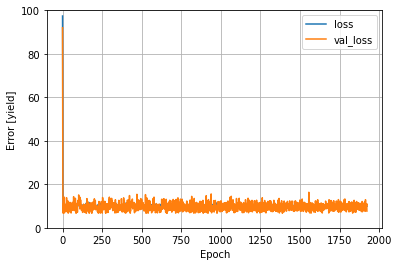

In [19]:
plot_loss(history)

In [20]:
def plot_prediction():
  plt.plot(predict, label="Prediction")
  plt.plot(testy_array, label="Actual")
  plt.xlim()
  plt.ylim()
  plt.xlabel('data points')
  plt.ylabel('Yield (gm/m2)')
  plt.legend()
  plt.grid(True)

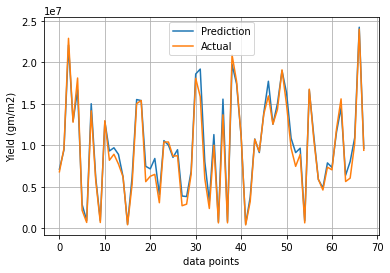

In [21]:
plot_prediction()

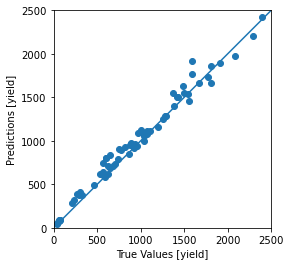

In [22]:
a = plt.axes(aspect='equal')
plt.scatter(testy_array/10000, predict/10000)
plt.xlabel('True Values [yield]')
plt.ylabel('Predictions [yield]')
lims = [0,2500]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)

In [34]:
from sklearn.metrics import r2_score, mean_squared_error

r2_score(testy_array, predict)

0.9726431885485556

In [32]:
MAPE_SVM = np.mean(abs((testy_array -  predict)/testy_array)) * 100

In [33]:
MAPE_SVM

240.31906127929688

In [42]:
df = pd.DataFrame(predict.numpy())
df

,0
0,7118360.5
1,9441778.0
2,22068194.0
3,12902078.0
4,16658739.0
...,...
63,6388786.0
64,8037828.0
65,10903153.0
66,24212682.0


In [43]:

df.to_csv('G:/giscourse/project/datatoMakemodel/ann_pred.csv', index=False)

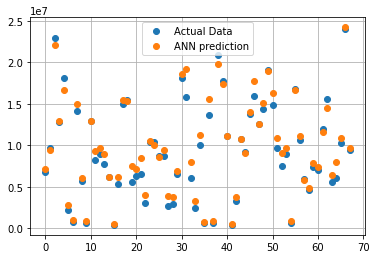

In [24]:
fig, ax = plt.subplots()
ax.plot(testy_array, "o", label="Actual Data")
# ax.plot(x1, y_true, "b-", label="True")
ax.plot(predict, "o", label="ANN prediction")
ax.legend(loc="best")
ax.grid(True)

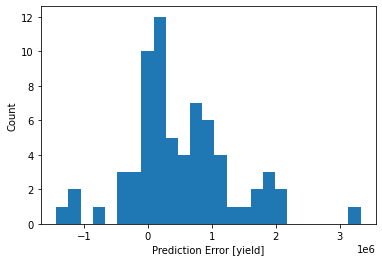

In [25]:
s=tf.transpose(predict)
error = s - testy_array
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [yield]')
_ = plt.ylabel('Count')

# Without Area

In [221]:
predictor_train_wo_A = train[['ndvi','gndvi','evi']]
corn_train_wo_A =train['yield_Bu_Acr_f']/14.8697
test_x_wo_A = test[['ndvi','gndvi','evi']]
test_y_wo_A = test['yield_Bu_Acr_f']

In [222]:
from sklearn.preprocessing import StandardScaler
sc_X_wo_A = StandardScaler()
sc_y_wo_A = StandardScaler()

In [223]:
predictor_array_wo_A = np.array(predictor_train_wo_A)
corn_train_array_wo_A = np.array(corn_train_wo_A)
testX_array_wo_A = np.array(test_x_wo_A)
testy_array_wo_A = np.array(test_y_wo_A)

In [224]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('val_loss')<5):
      print("\nReached max accuracy so cancelling training!")
      self.model.stop_training = True

In [225]:
callbacks = myCallback()

In [226]:
from tensorflow.keras import backend as K
def r2_keras(transtrain_labels_true, transtrain_labels_pred):
    SS_res =  K.sum(K.square(transtrain_labels_true - transtrain_labels_pred)) 
    SS_tot = K.sum(K.square(transtrain_labels_true - K.mean(transtrain_labels_true))) 
    return ( 1 - SS_res/(SS_tot + K.epsilon()))

In [227]:
model = tf.keras.Sequential([
   
    layers.Dense(180),
    layers.Dense(180), 
    layers.Dense(128),
    layers.Dense(64), 
    layers.Dense(32),
    
    layers.Dense(1)
])

model.compile(loss = tf.losses.MeanAbsolutePercentageError(),
                      optimizer = tf.optimizers.Adam(), metrics=['MeanAbsolutePercentageError','mse', 'mae', r2_keras])

In [228]:
history= model.fit(predictor_array_wo_A,corn_train_array_wo_A, epochs=3500, callbacks= [callbacks], validation_split= .2)

Epoch 1/3500
11/11 [==============================] - 0s 25ms/step - loss: 47.2499 - mean_absolute_percentage_error: 47.2499 - mse: 55.3991 - mae: 5.4127 - r2_keras: -28.4032 - val_loss: 20.6832 - val_mean_absolute_percentage_error: 20.6832 - val_mse: 8.1798 - val_mae: 2.5761 - val_r2_keras: -7.9066
Epoch 2/3500
11/11 [==============================] - 0s 5ms/step - loss: 17.9496 - mean_absolute_percentage_error: 17.9496 - mse: 7.5127 - mae: 2.0632 - r2_keras: -3.2146 - val_loss: 7.9941 - val_mean_absolute_percentage_error: 7.9941 - val_mse: 1.6964 - val_mae: 1.0082 - val_r2_keras: -0.8897
Epoch 3/3500
11/11 [==============================] - 0s 4ms/step - loss: 15.0221 - mean_absolute_percentage_error: 15.0221 - mse: 5.8329 - mae: 1.7407 - r2_keras: -2.2751 - val_loss: 9.1828 - val_mean_absolute_percentage_error: 9.1828 - val_mse: 1.9768 - val_mae: 1.1348 - val_r2_keras: -1.1709
Epoch 4/3500
11/11 [==============================] - 0s 4ms/step - loss: 14.7749 - mean_absolute_percentag

Epoch 29/3500
11/11 [==============================] - 0s 5ms/step - loss: 12.5725 - mean_absolute_percentage_error: 12.5725 - mse: 3.6830 - mae: 1.4493 - r2_keras: -1.0180 - val_loss: 9.6596 - val_mean_absolute_percentage_error: 9.6596 - val_mse: 2.2963 - val_mae: 1.1895 - val_r2_keras: -1.5137
Epoch 30/3500
11/11 [==============================] - ETA: 0s - loss: 9.9933 - mean_absolute_percentage_error: 9.9933 - mse: 2.2779 - mae: 1.1261 - r2_keras: -0.93 - 0s 6ms/step - loss: 15.8992 - mean_absolute_percentage_error: 15.8992 - mse: 5.3027 - mae: 1.8269 - r2_keras: -1.9239 - val_loss: 8.9414 - val_mean_absolute_percentage_error: 8.9414 - val_mse: 1.8524 - val_mae: 1.0961 - val_r2_keras: -1.0130
Epoch 31/3500
11/11 [==============================] - 0s 5ms/step - loss: 12.9858 - mean_absolute_percentage_error: 12.9858 - mse: 3.7183 - mae: 1.4753 - r2_keras: -1.1795 - val_loss: 9.4554 - val_mean_absolute_percentage_error: 9.4554 - val_mse: 2.1919 - val_mae: 1.2230 - val_r2_keras: -1.46

Epoch 84/3500
11/11 [==============================] - 0s 27ms/step - loss: 11.0586 - mean_absolute_percentage_error: 11.0586 - mse: 2.3792 - mae: 1.2324 - r2_keras: -0.2551 - val_loss: 5.7139 - val_mean_absolute_percentage_error: 5.7139 - val_mse: 0.7210 - val_mae: 0.7094 - val_r2_keras: 0.2096
Epoch 85/3500
11/11 [==============================] - 0s 10ms/step - loss: 10.3831 - mean_absolute_percentage_error: 10.3831 - mse: 2.0869 - mae: 1.1516 - r2_keras: -0.0810 - val_loss: 6.4823 - val_mean_absolute_percentage_error: 6.4823 - val_mse: 1.0765 - val_mae: 0.8240 - val_r2_keras: -0.2032
Epoch 86/3500
11/11 [==============================] - 0s 7ms/step - loss: 11.5586 - mean_absolute_percentage_error: 11.5586 - mse: 2.5670 - mae: 1.2838 - r2_keras: -0.4224 - val_loss: 6.2001 - val_mean_absolute_percentage_error: 6.2001 - val_mse: 0.8911 - val_mae: 0.7636 - val_r2_keras: 0.0241
Epoch 87/3500
11/11 [==============================] - 0s 6ms/step - loss: 13.0999 - mean_absolute_percentage

11/11 [==============================] - 0s 15ms/step - loss: 10.3505 - mean_absolute_percentage_error: 10.3505 - mse: 2.0906 - mae: 1.1431 - r2_keras: -0.1969 - val_loss: 7.6379 - val_mean_absolute_percentage_error: 7.6379 - val_mse: 1.4270 - val_mae: 0.9906 - val_r2_keras: -0.6125
Epoch 139/3500
11/11 [==============================] - 0s 12ms/step - loss: 11.2850 - mean_absolute_percentage_error: 11.2850 - mse: 2.3239 - mae: 1.2370 - r2_keras: -0.3074 - val_loss: 11.6823 - val_mean_absolute_percentage_error: 11.6823 - val_mse: 2.9113 - val_mae: 1.5174 - val_r2_keras: -2.2828
Epoch 140/3500
11/11 [==============================] - 0s 10ms/step - loss: 11.1745 - mean_absolute_percentage_error: 11.1745 - mse: 2.4904 - mae: 1.2676 - r2_keras: -0.3013 - val_loss: 11.0956 - val_mean_absolute_percentage_error: 11.0956 - val_mse: 2.7301 - val_mae: 1.4354 - val_r2_keras: -2.0965
Epoch 141/3500
11/11 [==============================] - 0s 11ms/step - loss: 11.5073 - mean_absolute_percentage_er

11/11 [==============================] - 0s 6ms/step - loss: 10.4020 - mean_absolute_percentage_error: 10.4020 - mse: 2.0549 - mae: 1.1440 - r2_keras: -0.1141 - val_loss: 11.4380 - val_mean_absolute_percentage_error: 11.4380 - val_mse: 2.8027 - val_mae: 1.4835 - val_r2_keras: -2.1665
Epoch 193/3500
11/11 [==============================] - 0s 8ms/step - loss: 11.3876 - mean_absolute_percentage_error: 11.3876 - mse: 2.4241 - mae: 1.2657 - r2_keras: -0.3279 - val_loss: 6.9342 - val_mean_absolute_percentage_error: 6.9342 - val_mse: 1.2469 - val_mae: 0.8976 - val_r2_keras: -0.4023
Epoch 194/3500
11/11 [==============================] - 0s 7ms/step - loss: 10.9904 - mean_absolute_percentage_error: 10.9904 - mse: 2.2947 - mae: 1.1967 - r2_keras: -0.3594 - val_loss: 7.0936 - val_mean_absolute_percentage_error: 7.0936 - val_mse: 1.2934 - val_mae: 0.9206 - val_r2_keras: -0.4572
Epoch 195/3500
11/11 [==============================] - 0s 5ms/step - loss: 10.1003 - mean_absolute_percentage_error: 1

...

Epoch 3366/3500
11/11 [==============================] - 0s 5ms/step - loss: 9.8388 - mean_absolute_percentage_error: 9.8388 - mse: 1.7877 - mae: 1.1000 - r2_keras: 0.0087 - val_loss: 7.6870 - val_mean_absolute_percentage_error: 7.6870 - val_mse: 1.4207 - val_mae: 0.9976 - val_r2_keras: -0.6137
Epoch 3367/3500
11/11 [==============================] - 0s 5ms/step - loss: 9.2602 - mean_absolute_percentage_error: 9.2602 - mse: 1.6041 - mae: 1.0250 - r2_keras: 0.1924 - val_loss: 5.4980 - val_mean_absolute_percentage_error: 5.4980 - val_mse: 0.7093 - val_mae: 0.6782 - val_r2_keras: 0.2235
Epoch 3368/3500
11/11 [==============================] - 0s 6ms/step - loss: 9.5272 - mean_absolute_percentage_error: 9.5272 - mse: 1.6889 - mae: 1.0599 - r2_keras: 0.0884 - val_loss: 5.5359 - val_mean_absolute_percentage_error: 5.5359 - val_mse: 0.6975 - val_mae: 0.6963 - val_r2_keras: 0.2239
Epoch 3369/3500
11/11 [==============================] - 0s 5ms/step - loss: 9.6723 - mean_absolute_percentage_err

Epoch 3394/3500
11/11 [==============================] - 0s 4ms/step - loss: 9.3483 - mean_absolute_percentage_error: 9.3483 - mse: 1.6274 - mae: 1.0338 - r2_keras: 0.0349 - val_loss: 7.1756 - val_mean_absolute_percentage_error: 7.1756 - val_mse: 1.2634 - val_mae: 0.9311 - val_r2_keras: -0.4385
Epoch 3395/3500
11/11 [==============================] - 0s 4ms/step - loss: 9.4221 - mean_absolute_percentage_error: 9.4221 - mse: 1.5999 - mae: 1.0296 - r2_keras: 0.1417 - val_loss: 6.6601 - val_mean_absolute_percentage_error: 6.6601 - val_mse: 1.1175 - val_mae: 0.8634 - val_r2_keras: -0.2667
Epoch 3396/3500
11/11 [==============================] - 0s 5ms/step - loss: 9.4122 - mean_absolute_percentage_error: 9.4122 - mse: 1.6948 - mae: 1.0641 - r2_keras: 0.1193 - val_loss: 5.8102 - val_mean_absolute_percentage_error: 5.8102 - val_mse: 0.8164 - val_mae: 0.7424 - val_r2_keras: 0.0817
Epoch 3397/3500
11/11 [==============================] - 0s 4ms/step - loss: 9.2193 - mean_absolute_percentage_er

Epoch 3422/3500
11/11 [==============================] - 0s 4ms/step - loss: 9.0718 - mean_absolute_percentage_error: 9.0718 - mse: 1.5311 - mae: 1.0113 - r2_keras: 0.1677 - val_loss: 5.8365 - val_mean_absolute_percentage_error: 5.8365 - val_mse: 0.8236 - val_mae: 0.7453 - val_r2_keras: 0.0651
Epoch 3423/3500
11/11 [==============================] - 0s 4ms/step - loss: 9.1402 - mean_absolute_percentage_error: 9.1402 - mse: 1.5681 - mae: 1.0190 - r2_keras: 0.1379 - val_loss: 5.6846 - val_mean_absolute_percentage_error: 5.6846 - val_mse: 0.7701 - val_mae: 0.7210 - val_r2_keras: 0.1289
Epoch 3424/3500
11/11 [==============================] - 0s 4ms/step - loss: 9.1692 - mean_absolute_percentage_error: 9.1692 - mse: 1.6269 - mae: 1.0389 - r2_keras: 0.1251 - val_loss: 5.6049 - val_mean_absolute_percentage_error: 5.6049 - val_mse: 0.7582 - val_mae: 0.6912 - val_r2_keras: 0.1689
Epoch 3425/3500
11/11 [==============================] - 0s 4ms/step - loss: 9.5420 - mean_absolute_percentage_erro

Epoch 3450/3500
11/11 [==============================] - 0s 4ms/step - loss: 9.1396 - mean_absolute_percentage_error: 9.1396 - mse: 1.5483 - mae: 1.0154 - r2_keras: 0.1384 - val_loss: 5.5074 - val_mean_absolute_percentage_error: 5.5074 - val_mse: 0.6966 - val_mae: 0.6879 - val_r2_keras: 0.2246
Epoch 3451/3500
11/11 [==============================] - 0s 4ms/step - loss: 9.1839 - mean_absolute_percentage_error: 9.1839 - mse: 1.5541 - mae: 1.0222 - r2_keras: 0.1693 - val_loss: 5.5022 - val_mean_absolute_percentage_error: 5.5022 - val_mse: 0.7005 - val_mae: 0.6881 - val_r2_keras: 0.2199
Epoch 3452/3500
11/11 [==============================] - 0s 4ms/step - loss: 9.4061 - mean_absolute_percentage_error: 9.4061 - mse: 1.6259 - mae: 1.0446 - r2_keras: 0.0668 - val_loss: 5.9219 - val_mean_absolute_percentage_error: 5.9219 - val_mse: 0.8532 - val_mae: 0.7583 - val_r2_keras: 0.0311
Epoch 3453/3500
11/11 [==============================] - 0s 4ms/step - loss: 9.2921 - mean_absolute_percentage_erro

Epoch 3478/3500
11/11 [==============================] - 0s 14ms/step - loss: 9.2501 - mean_absolute_percentage_error: 9.2501 - mse: 1.5743 - mae: 1.0264 - r2_keras: 0.1360 - val_loss: 6.0707 - val_mean_absolute_percentage_error: 6.0707 - val_mse: 0.9177 - val_mae: 0.7806 - val_r2_keras: -0.0435
Epoch 3479/3500
11/11 [==============================] - 0s 13ms/step - loss: 9.4482 - mean_absolute_percentage_error: 9.4482 - mse: 1.6437 - mae: 1.0444 - r2_keras: 0.1376 - val_loss: 8.0330 - val_mean_absolute_percentage_error: 8.0330 - val_mse: 1.5465 - val_mae: 1.0435 - val_r2_keras: -0.7636
Epoch 3480/3500
11/11 [==============================] - 0s 11ms/step - loss: 9.6776 - mean_absolute_percentage_error: 9.6776 - mse: 1.7229 - mae: 1.0796 - r2_keras: 0.0799 - val_loss: 5.8039 - val_mean_absolute_percentage_error: 5.8039 - val_mse: 0.8135 - val_mae: 0.7419 - val_r2_keras: 0.0811
Epoch 3481/3500
11/11 [==============================] - 0s 12ms/step - loss: 9.4108 - mean_absolute_percentag

In [229]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mean_absolute_percentage_error,mse,mae,r2_keras,val_loss,val_mean_absolute_percentage_error,val_mse,val_mae,val_r2_keras,epoch
3495,9.275947,9.275947,1.552110,1.020283,0.159935,6.292716,6.292716,0.974240,0.809977,-0.110340,3495
3496,9.452437,9.452437,1.737914,1.075056,0.071909,5.618059,5.618059,0.741612,0.711319,0.169762,3496
3497,9.386573,9.386573,1.611181,1.038443,0.086504,5.528353,5.528353,0.691998,0.694135,0.228607,3497
3498,9.083802,9.083802,1.507994,1.001261,0.205462,6.570095,6.570095,1.079294,0.849672,-0.230101,3498
3499,9.315870,9.315870,1.615369,1.044882,0.138529,5.773301,5.773301,0.798861,0.736189,0.097070,3499
